In [1]:
# the purpose of this code is to calculate the diffusion limited escape flux of total H
# and compute the ocean loss timescale
# the input values are calculated in the Jupyter notebook - MixingRatios 
# also awaiting for e0_branch data

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as ticker

In [2]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0) #open the file

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=2)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

In [3]:
# define eccentricity range

#e_range =['e0','e01','e02','e03','e04']

e_range =['e01','e02','e03','e04']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0_branch.001/atm/hist/')

# define specific path
          

Path_H2O        = []
Path_H2         = []
Path_H          = []
Path_CH4        = []
Path_H2O        = []
Path_H2O2       = []
Path_HO2        = []
Path_OH         = []

Path_T          = []




for i in range(len(data_dir_file)):
          
    Path_H2O.append(data_dir_file[i]+'H2O_'+ e_range[i] +'_obl0_merge.nc')
    Path_H2.append(data_dir_file[i]+'H2_'+ e_range[i] +'_obl0_merge.nc')
    Path_H.append(data_dir_file[i]+'H_'+ e_range[i] +'_obl0_merge.nc')
    Path_H2O2.append(data_dir_file[i]+'H2O2_'+ e_range[i] +'_obl0_merge.nc')
    Path_CH4.append(data_dir_file[i]+'CH4_'+ e_range[i] +'_obl0_merge.nc')
    Path_HO2.append(data_dir_file[i]+'HO2_'+ e_range[i] +'_obl0_merge.nc')
    Path_OH.append(data_dir_file[i]+'OH_'+ e_range[i] +'_obl0_merge.nc')
    
    Path_T.append(data_dir_file[i]+'T_'+ e_range[i] +'_obl0_merge.nc')



# Import data

# each file has 5 case elements

H2_obl0           =[]
H_obl0            =[]
H2O2_obl0         =[]
HO2_obl0          =[]
CH4_obl0          =[]
OH_obl0           =[]
H2O_obl0          =[]

T_obl0            =[]



for i in range(len(e_range)):

          
    H2_obl0.append(xr.open_mfdataset(Path_H2[i]))
    H_obl0.append(xr.open_mfdataset(Path_H[i]))
    H2O2_obl0.append(xr.open_mfdataset(Path_H2O2[i]))
    HO2_obl0.append(xr.open_mfdataset(Path_HO2[i]))
    CH4_obl0.append(xr.open_mfdataset(Path_CH4[i]))
    OH_obl0.append(xr.open_mfdataset(Path_OH[i]))
    H2O_obl0.append(xr.open_mfdataset(Path_H2O[i]))
    T_obl0.append(xr.open_mfdataset(Path_T[i]))


In [4]:
OH_e04_global=LatWeightAnyVar(OH_obl0[3].OH[0:72,:,:,:])
OH_e01_global=LatWeightAnyVar(OH_obl0[0].OH[0:72,:,:,:])

H2O2_e04_global=LatWeightAnyVar(H2O2_obl0[3].H2O2[0:72,:,:,:])
H2O2_e01_global=LatWeightAnyVar(H2O2_obl0[0].H2O2[0:72,:,:,:])

CH4_e04_global=LatWeightAnyVar(CH4_obl0[3].CH4[0:72,:,:,:])
CH4_e01_global=LatWeightAnyVar(CH4_obl0[0].CH4[0:72,:,:,:])

H2_e04_global=LatWeightAnyVar(H2_obl0[3].H2[0:72,:,:,:])
H2_e01_global=LatWeightAnyVar(H2_obl0[0].H2[0:72,:,:,:])

HO2_e04_global=LatWeightAnyVar(HO2_obl0[3].HO2[0:72,:,:,:])
HO2_e01_global=LatWeightAnyVar(HO2_obl0[0].HO2[0:72,:,:,:])

H_e04_global=LatWeightAnyVar(H_obl0[3].H[0:72,:,:,:])
H_e01_global=LatWeightAnyVar(H_obl0[0].H[0:72,:,:,:])

H2O_e04_global=LatWeightAnyVar(H2O_obl0[3].H2O[0:72,:,:,:])
H2O_e01_global=LatWeightAnyVar(H2O_obl0[0].H2O[0:72,:,:,:])

T_e04_global=LatWeightAnyVar(T_obl0[3].T[0:72,:,:,:])
T_e01_global=LatWeightAnyVar(T_obl0[0].T[0:72,:,:,:])


In [5]:
OH_e04_top= OH_e04_global.isel(lev=0)
OH_e01_top= OH_e01_global.isel(lev=0)

H2O2_e04_top= H2O2_e04_global.isel(lev=0)
H2O2_e01_top= H2O2_e01_global.isel(lev=0)

CH4_e04_top= CH4_e04_global.isel(lev=0)
CH4_e01_top= CH4_e01_global.isel(lev=0)

H2_e04_top= H2_e04_global.isel(lev=0)
H2_e01_top= H2_e01_global.isel(lev=0)

HO2_e04_top= HO2_e04_global.isel(lev=0)
HO2_e01_top= HO2_e01_global.isel(lev=0)

H_e04_top= H_e04_global.isel(lev=0)
H_e01_top= H_e01_global.isel(lev=0)

H2O_e04_top= H2O_e04_global.isel(lev=0)
H2O_e01_top= H2O_e01_global.isel(lev=0)

T_e04_top= T_e04_global.isel(lev=0)
T_e01_top= T_e01_global.isel(lev=0)

In [6]:
H_total_e01=OH_e01_top+2*H2O2_e01_top+4*CH4_e01_top+2*H2_e01_top+HO2_e01_top+2*H2O_e01_top+H_e01_top

H_total_e04=OH_e04_top+2*H2O2_e04_top+4*CH4_e04_top+2*H2_e04_top+HO2_e04_top+2*H2O_e04_top+H_e04_top

In [23]:
def H_flux(T, T_thermo, H_thermo, H2_thermo):

# thermospheric temperature at model top
# I would intend to take global mean for this value 

    b_H        = (4.8*10**17)*T_thermo**0.7 
    
    print(b_H.mean(dim='time').values)
    
# for single H atom, A=4.8*10**17
# if consider more, such as H2, needs to use weighted b12=(b_h*n_h+b_h2*n_h2)/(n_h+n_h2)

    b_H2       = (2.7*10**17)*T_thermo**0.7 

    n_h1       = H_thermo
    
    n_h2       = H2_thermo


    
    b_weighted=(b_h*n_h+b_h2*n_h2)/(n_h+n_h2)
    
    print(b_weighted.mean(dim='time').values)
    
    f_tot     =  H_thermo + 2*H2_thermo
    
# source: 
#Catling, David C.; Kasting, James F. (2017). 
#Atmospheric Evolution on Inhabited and Lifeless Worlds. 
#Cambridge: Cambridge University Press. 
#doi:10.1017/9781139020558. ISBN 9781139020558.

# thermospheric hydrogen mixing ratio (model top)
# I would intend to take global mean for this value 

    K        = 1.38 * 10**(-23) # J·K−1

    T_air    = T.mean(dim='lev') # # atmospheric mean temperature in K

    u        = 1.660*10**(-27) # hydrogen mass in kg

    m        = 28.964 * u # mean atmospheric molecular mass in kg

    g        = 9.8 # m/s2

    H        = (K*T_air/m*g)*100  # in cm

    Phi_H =b_weighted *f_tot /H 

    return Phi_H #/m^2

# goal: plot it as a function of time for each eccentricity

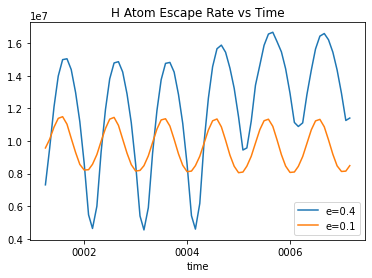

In [10]:
H_flux(T_e04_global,T_e04_top,H_e04_top).plot(label='e=0.4')

H_flux(T_e01_global,T_e01_top,H_e01_top).plot(label='e=0.1')



# H_flux(T_e01_global,T_e01_top,H_total_e01).plot(label='e=0.1 total')

# H_flux(T_e04_global,T_e04_top,H_total_e04).plot(label='e=0.4 total')

plt.title("H Atom Escape Rate vs Time")

plt.legend()

4.3115172057475146e+19
2.7299999999999214e+19
4.252499290288513e+19
2.7299999999999214e+19


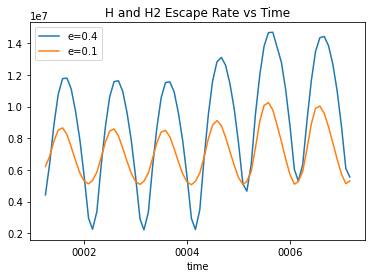

In [24]:
H_flux(T_e04_global,T_e04_top,H_e04_top,H2_e04_top).plot(label='e=0.4')
H_flux(T_e01_global,T_e01_top,H_e01_top,H2_e04_top).plot(label='e=0.1')
plt.title("H and H2 Escape Rate vs Time")

plt.legend()

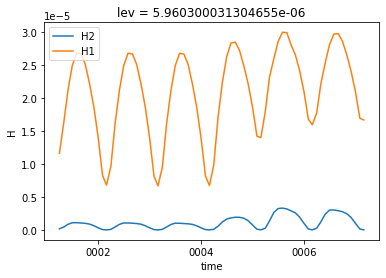

In [20]:
H2_e04_top.plot(label='H2')
H_e04_top.plot(label='H1')
plt.legend()